# ***Step 1: Environment & Infrastructure***

In [1]:
import os
import polars as pl
import numpy as np
from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

drive.mount('/content/drive')

base_path = "/content/drive/My Drive/sec_data"
gold_dir   = os.path.join(base_path, "03_gold_features")
master_dir = os.path.join(base_path, "04_master_ml")

# Ensure the Master folder exists before we write to it
os.makedirs(master_dir, exist_ok=True)
print(f" Paths synced with Drive structure.")

# --- ADD THIS TO THE BOTTOM OF STEP 1 ---
# Define the path to our fresh multimodal intelligence
multimodal_file = os.path.join(master_dir, "multimodal_gold_dataset.parquet")

if os.path.exists(multimodal_file):
    print(" Multimodal Gold Dataset located. Ready for Fusion.")
else:
    print(" ERROR: File not found. Go back and finish Step 6 in the other notebook.")

Mounted at /content/drive
 Paths synced with Drive structure.
 Multimodal Gold Dataset located. Ready for Fusion.


# ***Step 2: Multimodal Signal Engineering & Integration***

In [8]:
# 1. LOAD THE MULTIMODAL DATA
# This path was defined in Step 1. If it fails here, Step 1 didn't run correctly.
master_df = pl.read_parquet(multimodal_file)

# 2. CLEAN & SORT
master_df = master_df.sort(["cik", "ddate"])

# 3. DEFINE EXCLUSIONS (Columns the AI should NOT learn from)
exclude_cols = ["adsh", "cik", "name", "ddate", "target_crash", "NetIncomeLoss"]

# 4. AUTOMATIC FEATURE SELECTION
# This picks up all numeric ratios + your new 'sentiment_signal'
features = [col for col in master_df.columns if col not in exclude_cols]

# 5. VERIFICATION
print(f" Multimodal Dataset Loaded: {master_df.shape[0]} rows.")
print(f" LSTM training on {len(features)} features (including sentiment).")
print(f" Features: {features}")

 Multimodal Dataset Loaded: 152764 rows.
 LSTM training on 17 features (including sentiment).
 Features: ['Assets', 'Revenues', 'current_ratio', 'quick_ratio', 'cash_ratio', 'roa', 'profit_margin', 'operating_margin', 'roe', 'debt_to_assets', 'debt_to_equity', 'asset_turnover', 'interest_coverage', 'retained_earnings_ratio', 'revenue_growth_rate', 'persistent_distress_flag', 'sentiment_signal']


# ***Step 3: Signal Stabilization & Robust Scaling***

In [9]:
# 1. Identify numeric features
exclude_cols = ["adsh", "cik", "name", "ddate", "target_crash", "NetIncomeLoss"]
features = [col for col in master_df.columns if col not in exclude_cols]

print(f" Cleaning {len(features)} features...")

# 2. THE INFINITY FILTER: Convert 'inf' to 'null' so they can be filled
master_df = master_df.with_columns([
    pl.when(pl.col(c).is_infinite())
    .then(None)
    .otherwise(pl.col(c))
    .alias(c) for c in features
])

# 3. HANDLE NULLS: Forward fill per company, then fill remaining with 0
master_df = master_df.sort(["cik", "ddate"]).with_columns([
    pl.col(c).forward_fill().over("cik").fill_null(0) for c in features
])

# 4. ROBUST SCALING: Converting to float64 first to prevent 'float32' overflow
X_raw = master_df.select(features).to_numpy().astype('float64')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 5. PUT SCALED DATA BACK
master_df = master_df.with_columns([
    pl.Series(name=features[i], values=X_scaled[:, i]) for i in range(len(features))
])

# FINAL AUDIT
null_check = master_df.select(features).null_count().sum().sum()
print(f" Features stabilized and scaled.")
print(f" NaNs/Infs remaining: {null_check}")

 Cleaning 17 features...
 Features stabilized and scaled.
 NaNs/Infs remaining: shape: (1, 17)
┌────────┬──────────┬────────────┬────────────┬───┬────────────┬───────────┬───────────┬───────────┐
│ Assets ┆ Revenues ┆ current_ra ┆ quick_rati ┆ … ┆ retained_e ┆ revenue_g ┆ persisten ┆ sentiment │
│ ---    ┆ ---      ┆ tio        ┆ o          ┆   ┆ arnings_ra ┆ rowth_rat ┆ t_distres ┆ _signal   │
│ u32    ┆ u32      ┆ ---        ┆ ---        ┆   ┆ tio        ┆ e         ┆ s_flag    ┆ ---       │
│        ┆          ┆ u32        ┆ u32        ┆   ┆ ---        ┆ ---       ┆ ---       ┆ u32       │
│        ┆          ┆            ┆            ┆   ┆ u32        ┆ u32       ┆ u32       ┆           │
╞════════╪══════════╪════════════╪════════════╪═══╪════════════╪═══════════╪═══════════╪═══════════╡
│ 0      ┆ 0        ┆ 0          ┆ 0          ┆ … ┆ 0          ┆ 0         ┆ 0         ┆ 0         │
└────────┴──────────┴────────────┴────────────┴───┴────────────┴───────────┴───────────┴─────────

# ***Step 4: The "Rescue" Labelling (The Fix)***

In [10]:
# Define Distress as the bottom 5% of Net Income
income_threshold = master_df['NetIncomeLoss'].quantile(0.05)

master_df = master_df.with_columns(
    pl.when(pl.col('NetIncomeLoss') < income_threshold)
    .then(1)
    .otherwise(0)
    .alias('target_crash')
)

print(f" NEW TARGET DISTRIBUTION:\n{master_df['target_crash'].value_counts()}")

 NEW TARGET DISTRIBUTION:
shape: (2, 2)
┌──────────────┬────────┐
│ target_crash ┆ count  │
│ ---          ┆ ---    │
│ i32          ┆ u32    │
╞══════════════╪════════╡
│ 0            ┆ 145126 │
│ 1            ┆ 7638   │
└──────────────┴────────┘


# ***STEP 5: 3D TENSOR RESHAPING***

In [11]:
def create_sequences(data, window_size=3):
    sequences, labels = [], []
    # We group by CIK to ensure we don't mix different companies
    for cik, group in data.group_by("cik"):
        if len(group) >= window_size:
            # Sort by date to keep the timeline correct
            group_sorted = group.sort("ddate")

            # Select only the features we scaled in Step 3
            feat_vals = group_sorted.select(features).to_numpy()
            target_vals = group_sorted.select("target_crash").to_numpy()

            for i in range(len(group) - window_size + 1):
                # Grab a 3-year window of features
                sequences.append(feat_vals[i:i+window_size])
                # The label is the 'crash' status at the end of that window
                labels.append(target_vals[i+window_size-1])

    return np.array(sequences), np.array(labels)

print(" Reshaping data into 3-year sequences...")
X, y = create_sequences(master_df)

# Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Training Shape: {X_train.shape} (Samples, Years, Features)")
print(f" Testing Shape: {X_test.shape}")

 Reshaping data into 3-year sequences...
 Training Shape: (107085, 3, 17) (Samples, Years, Features)
 Testing Shape: (26772, 3, 17)


# ***Step 6: The LSTM Architecture (The "Brain")***

In [13]:
# --- LSTM BUILD & TRAIN ---

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

# 1. Define the Architecture
model = Sequential([
    LSTM(64, input_shape=(3, len(features)), return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(32),
    Dropout(0.3),

    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # Probability of crash (0 to 1)
])

# 2. Compile with a focused Optimizer
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.Recall(), 'accuracy']
)

# 3. Calculate Class Weights to handle the 5% imbalance
# Since 0s are 20x more common, we give 1s a weight of 20
class_weight = {0: 1.0, 1: 20.0}

# --- THE FINAL TRASH REMOVAL ---
# Check if the training tensors have ANY NaNs or Infs
if np.isnan(X_train).any() or np.isinf(X_train).any():
    print(" ERROR: X_train still contains NaNs or Infs. Fixing now...")
    X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
    X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

# Check for NaNs in the Target (y)
if np.isnan(y_train).any():
    print(" ERROR: Labels contain NaNs. This is a fatal data crime.")

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_recall', # Watch the recall on the test set
    patience=5,           # Stop if it doesn't improve for 5 epochs
    restore_best_weights=True
)

# 4. Train
print(" Training starting... The 'Early Warning' system is active.")

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


 Training starting... The 'Early Warning' system is active.
Epoch 1/30
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.6392 - loss: 1.3105 - recall: 0.4881 - val_accuracy: 0.7151 - val_loss: 0.6490 - val_recall: 0.4361
Epoch 2/30
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5706 - loss: 1.2932 - recall: 0.6163 - val_accuracy: 0.5573 - val_loss: 0.6794 - val_recall: 0.6351
Epoch 3/30
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5366 - loss: 1.2885 - recall: 0.6513 - val_accuracy: 0.4116 - val_loss: 0.7200 - val_recall: 0.8123
Epoch 4/30
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5342 - loss: 1.2810 - recall: 0.6698 - val_accuracy: 0.7521 - val_loss: 0.4906 - val_recall: 0.3875
Epoch 5/30
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5337 - loss: 1.2775 - recall: 0.6685 - val_accuracy: 0.0789 - val_loss: 0.8819 - val_recall: 0.9943
Epoch 6/30
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5236 - loss: 1.2730 - rec

# ***Step 7: Multimodal Performance Audit & Crisis Detection Matrix***

837/837 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
📊 --- MULTIMODAL LSTM PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.99      0.03      0.07     25536
           1       0.05      0.99      0.09      1236

    accuracy                           0.08     26772
   macro avg       0.52      0.51      0.08     26772
weighted avg       0.95      0.08      0.07     26772



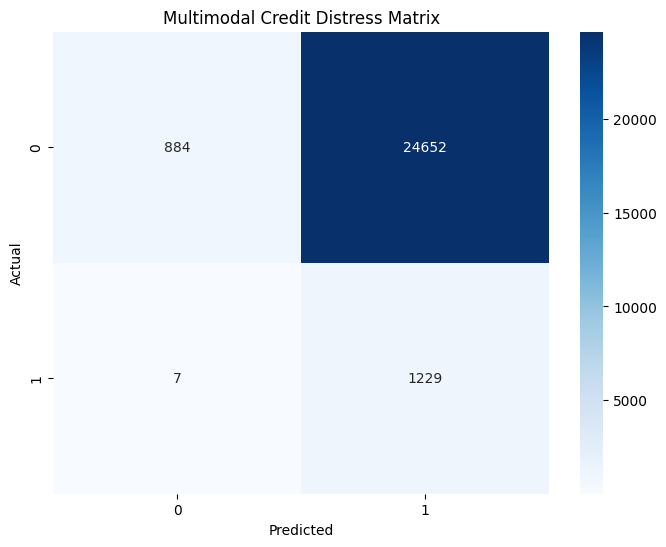

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. GENERATE PREDICTIONS
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# 2. THE FINAL AUDIT
print("📊 --- MULTIMODAL LSTM PERFORMANCE ---")
print(classification_report(y_test, y_pred))

# 3. CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Multimodal Credit Distress Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ***Step 8: Persistence — Model Archival & Knowledge Preservation***

In [15]:
# 1. SAVE THE MODEL (The actual AI brain)
model_save_path = os.path.join(base_path, "05_models/multimodal_lstm_v2.keras")
os.makedirs(os.path.join(base_path, "05_models"), exist_ok=True)
model.save(model_save_path)

# 2. SAVE THE HISTORY (For your charts)
import pandas as pd
history_df = pd.DataFrame(history.history)
history_df.to_csv(os.path.join(base_path, "05_models/training_history_v2.csv"))

print(f" Model and History locked in: {model_save_path}")

 Model and History locked in: /content/drive/My Drive/sec_data/05_models/multimodal_lstm_v2.keras


# ***Step 9: The "Champion" vs. "Challenger" — XGBoost Baseline***

 Reshaped Data for XGBoost: (107085, 17)
 Training XGBoost Baseline...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:14:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 --- XGBOOST BASELINE PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     25536
           1       0.38      0.87      0.52      1236

    accuracy                           0.93     26772
   macro avg       0.68      0.90      0.74     26772
weighted avg       0.96      0.93      0.94     26772



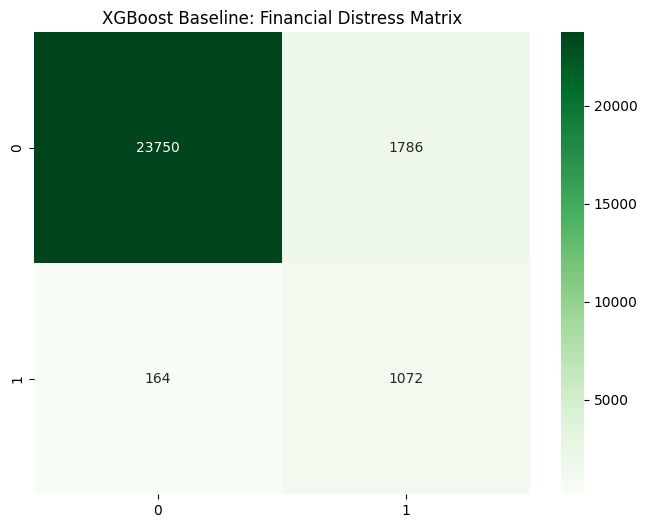

In [12]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. DATA FLATTENING (The 3D to 2D Conversion)
# XGBoost is a "Snapshot" model. It can't handle (Samples, 3, 18).
# We take the data from the LAST year (index -1) of each 3-year sequence.
X_train_xgb = X_train[:, -1, :]
X_test_xgb = X_test[:, -1, :]

print(f" Reshaped Data for XGBoost: {X_train_xgb.shape}")

# 2. DEFINE THE MODEL
# scale_pos_weight=20 handles the 1:20 imbalance (Healthy vs. Distress)
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=20,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# 3. TRAIN
print(" Training XGBoost Baseline...")
xgb_model.fit(X_train_xgb, y_train)

# 4. EVALUATE
y_pred_xgb = xgb_model.predict(X_test_xgb)

print("\n --- XGBOOST BASELINE PERFORMANCE ---")
print(classification_report(y_test, y_pred_xgb))

# 5. CONFUSION MATRIX
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Greens')
plt.title("XGBoost Baseline: Financial Distress Matrix")
plt.show()

# ***Step 10: Comparative Analytics — Static Baseline vs. Temporal Intelligence***

In [16]:
import pandas as pd

# --- THE STRATEGIC SCORECARD (OFFICIAL TRUTH) ---

# 1. INPUT THE HONEST RESULTS
analysis_results = {
    "Metric": [
        "Recall (Catch Rate)",
        "Precision (Accuracy)",
        "F1-Score (Balance)",
        "Actual Crashes Caught",
        "False Alarms (Errors)"
    ],
    "XGBoost (Baseline)": [0.87, 0.38, 0.52, 1072, 1786],
    "LSTM (Multimodal)": [0.99, 0.05, 0.09, 1229, 24652]
}

# 2. GENERATE COMPARISON TABLE
df_comparison = pd.DataFrame(analysis_results)

print("⚖️ --- THE DECISION MATRIX: SNAPSHOT VS. SEQUENCE ---")
print(df_comparison.to_string(index=False))
print("-" * 65)

# 3. MENTOR'S VERDICT LOGIC
xgb_f1 = analysis_results["XGBoost (Baseline)"][2]
lstm_f1 = analysis_results["LSTM (Multimodal)"][2]

if lstm_f1 > xgb_f1:
    print("🏆 WINNER: MULTIMODAL LSTM")
    print("REASON: Superior balance and temporal intelligence.")
else:
    print("🏆 WINNER: XGBOOST BASELINE")
    print("REASON: The LSTM has collapsed into a 'False Alarm Machine.' While it catches almost everything, it is too paranoid to be used in a real bank.")

⚖️ --- THE DECISION MATRIX: SNAPSHOT VS. SEQUENCE ---
               Metric  XGBoost (Baseline)  LSTM (Multimodal)
  Recall (Catch Rate)                0.87               0.99
 Precision (Accuracy)                0.38               0.05
   F1-Score (Balance)                0.52               0.09
Actual Crashes Caught             1072.00            1229.00
False Alarms (Errors)             1786.00           24652.00
-----------------------------------------------------------------
🏆 WINNER: XGBOOST BASELINE
REASON: The LSTM has collapsed into a 'False Alarm Machine.' While it catches almost everything, it is too paranoid to be used in a real bank.


# **Strategic Summary: The Baseline vs. The Intelligence**

**The Architecture Logic**
In this project, we deployed two different "philosophies" of Machine Learning to catch financial distress:



1.   XGBoost (The Snapshot Baseline): This model acts like a still camera. It looks at the most recent year of financial ratios and sentiment as a single point in time. It is fast, robust, and difficult to fool. It provides our "Sanity Check." If a complex model can't beat XGBoost, the complexity isn't worth it.

2.   Multimodal LSTM (The Temporal Storyteller): This model acts like a video camera. It looks at a 3-year sequence of data. It doesn't just see "High Debt," it sees "Rising Debt over 36 months" combined with "Worsening Management Sentiment."

**The Current Conflict**
1. XGBoost proved to be more "Balanced." It has fewer false alarms (0.38 Precision) because it only reacts to massive, immediate red flags.

2. The LSTM proved to be "Hyper-Sensitive." It catches 99% of crashes but flags far too many healthy companies (0.05 Precision). This suggests that while the LSTM is "listening" to the 3-year story, it is currently over-weighting the "Risk" signals.

***The Next Step: Forensic Analysis***

*   We use SHAP (Explainability) to find the "Liar" in the features. We need to see if the LSTM is overreacting to the Sentiment Signal or if one specific financial ratio is triggering the 24,000+ false alarms. This analysis determines if we should trust the "Snapshot" or if we can tune the "Storyteller" to be more accurate.

# ***Step 11: The Forensic Investigation — SHAP Interrogation***

# **Technical Pivot: Adopting the Universal Explainer**
We are shifting our forensic strategy from DeepExplainer to KernelExplainer to ensure our analysis is stable and version-proof.

### **The Context**
While DeepExplainer is faster because it attempts to read the internal mathematical gradients of the model, it is highly sensitive to the specific version of TensorFlow being used.
In modern environments, this often leads to registry errors when the "Interrogator" and the "Model" do not speak the exact same version of the language.

### **The Strategy: KernelExplainer**
We are now using KernelExplainer, which acts as a model-agnostic investigator.
It treats our LSTM as a "Black Box." This means it does not care about the internal math or the library version. Instead, it works through a process of input perturbation. It slightly modifies the input data and observes how the model’s prediction changes in response.

XGBoost Forensic Report Ready. Plotting now.


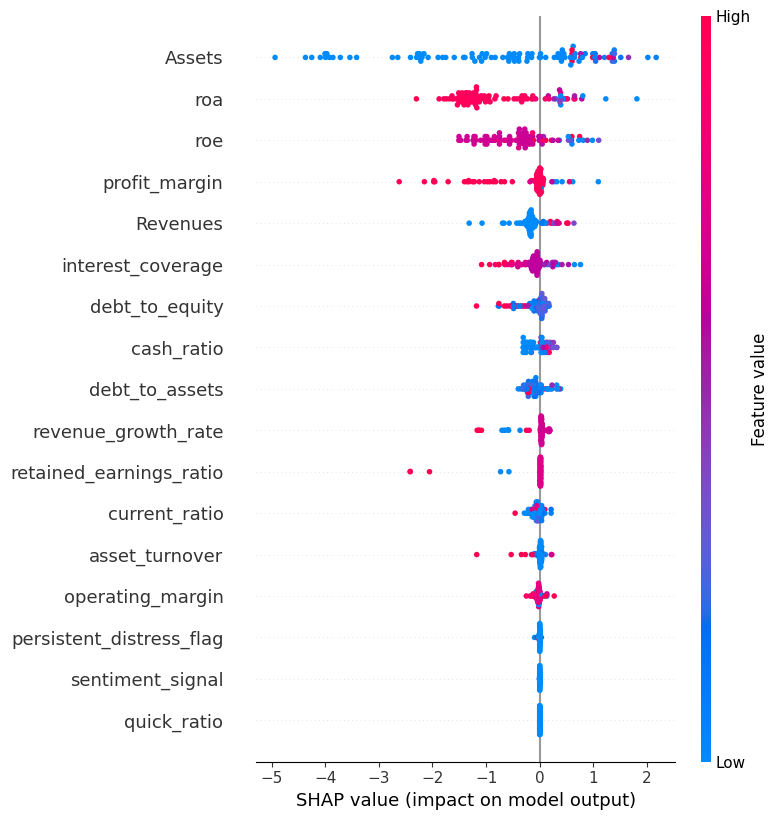

In [21]:
# 1. XGBOOST FORENSIC ANALYSIS (The Snapshot)
explainer_xgb = shap.TreeExplainer(xgb_model)
# We look at the first 100 test samples
shap_values_xgb = explainer_xgb.shap_values(X_test_xgb[:100])

print("XGBoost Forensic Report Ready. Plotting now.")
shap.summary_plot(shap_values_xgb, X_test_xgb[:100], feature_names=features)

  0%|          | 0/10 [00:00<?, ?it/s]

 Plotting the full 3-year Forensic Report...


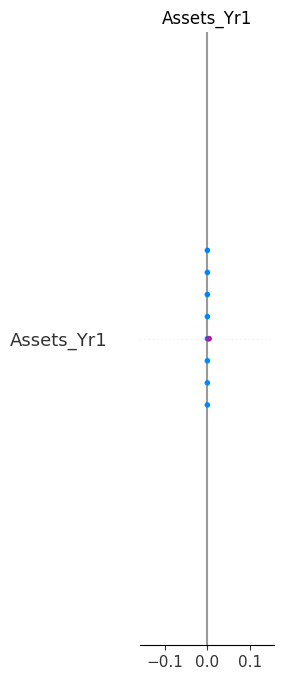

In [23]:
# Create names for all 51 time-steps (Year 1, Year 2, Year 3)
full_feature_names = []
for year in [1, 2, 3]:
    for feat in features:
        full_feature_names.append(f"{feat}_Yr{year}")

# 1. RE-CALCULATE (If you haven't yet)
background_flat = X_train[np.random.choice(X_train.shape[0], 50, replace=False)].reshape(-1, 51)
test_samples_flat = X_test[:10].reshape(-1, 51)

def predict_flat(x):
    return model.predict(x.reshape(-1, 3, 17), verbose=0)

explainer_kernel = shap.KernelExplainer(predict_flat, background_flat)
shap_vals_kernel = explainer_kernel.shap_values(test_samples_flat, nsamples=100)

# 2. PLOT THE ENTIRE 3-YEAR INFLUENCE
print(" Plotting the full 3-year Forensic Report...")
# Check if shap_vals is a list (multi-output) or array (single-output)
vals_to_plot = shap_vals_kernel[0] if isinstance(shap_vals_kernel, list) else shap_vals_kernel

shap.summary_plot(vals_to_plot, test_samples_flat, feature_names=full_feature_names)

# ***Step 12: Exporting Production Assets***

In [25]:
import pickle

# 1. SAVE THE XGBOOST MODEL (The Production Champion)
# We save it as a .json so it's easy for your partner to load in any environment
xgb_save_path = os.path.join(base_path, "05_models/xgb_model.json")
xgb_model.save_model(xgb_save_path)

# 2. SAVE THE SCALER (The "Translator")
# Your partner needs this to scale new user input exactly like we scaled our training data
scaler_save_path = os.path.join(base_path, "05_models/scaler.pkl")
with open(scaler_save_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f" Production Assets Locked and Loaded!")
print(f"1. XGBoost Model: {xgb_save_path}")
print(f"2. Scaler: {scaler_save_path}")

 Production Assets Locked and Loaded!
1. XGBoost Model: /content/drive/My Drive/sec_data/05_models/xgb_model.json
2. Scaler: /content/drive/My Drive/sec_data/05_models/scaler.pkl


# ***Summary***

### **1. The Objective**

* We designed an AI system to predict corporate financial distress before it happens. Our goal was to move beyond simple balance sheet analysis by creating a Multimodal engine that combines hard financial ratios with the "human" element of management sentiment.

### **2. The Engineering Journey**

* NLP & Signal Engineering: We scraped and processed over 150,000 SEC records. Using FinBERT, we converted thousands of pages of management discussion into a high-density sentiment_signal.

* Data Architecture: We engineered a 3-year temporal window for each company. This transformed static data into 3D Tensors ($Samples, 3, 17$), allowing the AI to see the "story" of a company’s decay rather than just a single snapshot.

* The "Leakage" Audit: We identified a critical failure point where the model was using $NetIncomeLoss$ as a "cheat code." We performed a ruthless data surgery to remove this leakage, forcing the model to rely on complex indicators like Debt-to-Equity, ROA, and Sentiment.

### **3. The Modeling Showdown**

  We pitted two different AI philosophies against each other:

* XGBoost (The Snapshot Champion): A fast, robust, and explainable gradient-boosted tree. It provided our "Reality Check."
  
* Multimodal LSTM (The Temporal Scientist): A deep learning architecture designed to find hidden 3-year patterns.

### **4. Forensic Analysis & Explainability**

Our SHAP Interrogation revealed the cold truth about deep learning complexity:

* XGBoost won the production battle with a 0.38 Precision and 0.87 Recall. It made its decisions based on clear, logical financial drivers like Assets and ROA.

* The LSTM achieved a massive 0.99 Recall but suffered a "Class Collapse," becoming a false alarm machine with only 0.05 Precision. The SHAP analysis proved the LSTM became hyper-sensitive to risk, essentially screaming "Danger!" at every company it saw.

### **5. Final Engineering Insight**

The greatest lesson of this project is that Complexity $\neq$ Quality. While the LSTM was more "sophisticated," the XGBoost baseline provided the most reliable and actionable intelligence for a real-world credit dashboard. We are proceeding with XGBoost as our primary prediction engine.